# 3.1 Coverage of protected areas and other effective area-based conservation measures

In [1]:
import datetime
now = datetime.datetime.now()
print(f"Última actualización de este notebook: {now.strftime('%d-%m-%Y %H:%M')}")

Última actualización de este notebook: 30-04-2026 20:50


El Indicador de Cabecera 3.1 evalúa la extensión y representatividad ecológica de los sistemas de conservación del país. Para este ciclo de reporte, el indicador cuantifica exclusivamente el porcentaje del territorio jurisdiccional y de sus ecosistemas (Grupos Funcionales de Ecosistemas, EFG) que se encuentra resguardado bajo figuras de Áreas Protegidas e iniciativas de conservación privada reconocidas. Su objetivo es monitorear el progreso hacia la meta de conservar al menos el 30% de las áreas terrestres, de aguas continentales y marinas, garantizando que esta protección sea ecológicamente representativa de la biodiversidad nacional.
Los metadatos oficiales del indicador se encuentran disponibles [aquí](https://www.gbf-indicators.org/metadata/headline/3-1).

## Metodología de Cálculo
La metodología de cálculo inició con la recopilación y sistematización de la información espacial oficial del país. Desde el geoportal del Sistema de Información de Biodiversidad (SIMBIO) se descargaron tres capas principales:
1. **Áreas Protegidas**: que incluye las designaciones de Parque Nacional, Reserva Nacional, Monumento Natural, Área de Conservación de Múltiples Usos y Santuario de la Naturaleza.
2. **Otras Designaciones**: que agrupa a los Sitios Ramsar y Bienes Nacionales Protegidos.
3. **Conservación Privada**: que compila las iniciativas de conservación en tierras privadas.

Para evitar solapamientos espaciales territoriales o doble contabilidad entre las distintas figuras (p. ej., un Sitio Ramsar que también es un Santuario de la Naturaleza), se realizó un proceso de disolución y unificación geométrica, generando una única capa consolidada de áreas protegidas nacionales.

Posteriormente, esta capa unificada fue intersectada espacialmente con la cartografía nacional de Grupos Funcionales de Ecosistemas (EFG). El cálculo de representatividad consistió en dividir la superficie protegida de cada EFG (numerador) por la superficie total cartografiada de dicho ecosistema a nivel nacional (denominador), obteniendo así el porcentaje (%) cubierto por la red de conservación. Al igual que en los reportes previos, se excluyó el cálculo de la gestión efectiva y la cobertura de KBA debido a la falta de métricas estandarizadas y a la incompatibilidad normativa de esta última figura en Chile.

## Fuentes de Datos Utilizadas
La información espacial utilizada para el cálculo de este indicador proviene directamente del geoportal del Sistema de Información de Biodiversidad de Chile (SIMBIO, https://simbio.mma.gob.cl/). Para construir la superficie total de conservación, se descargaron y procesaron tres capas vectoriales principales:
1. **Áreas Protegidas**: Capa que incluye las designaciones oficiales de Parque Nacional, Reserva Nacional, Monumento Natural, Área de Conservación de Múltiples Usos y Santuario de la Naturaleza.
2. **Otras Designaciones**: Capa que agrupa los polígonos correspondientes a Sitios Ramsar y Bienes Nacionales Protegidos.
3. **Conservación Privada**: Capa que compila las iniciativas formalizadas de conservación en tierras de propiedad privada.
Por otra parte, para realizar la desagregación espacial de la representatividad ecológica exigida por el indicador, se estructuró una capa cartográfica unificada de Grupos Funcionales de Ecosistemas (EFG). Esta capa base se construyó a partir de la homologación e integración técnica de cuatro fuentes y registros oficiales del Estado:
* La clasificación de Pisos Vegetacionales de Chile (Luebert & Pliscoff, 2015) para el ámbito terrestre.
* El marco ecorregional de Ecosistemas Marinos (Rovira y Herreros, 2016) para el ámbito marítimo.
* El Inventario Nacional de Humedales para los ecosistemas dulceacuícolas y transicionales.
* El Inventario Nacional de Glaciares para los ecosistemas criosféricos.

En el caso de las capas vectoriales, se utilizaron las siguientes url de la API Arcgis de SIMBIO

In [2]:
LAYER_AP_URLS = [
    "https://arcgis.mma.gob.cl/server/rest/services/SIMBIO/SIMBIO_AP/FeatureServer/0", #Áreas Protegidas
    "https://arcgis.mma.gob.cl/server/rest/services/SIMBIO/SIMBIO_AP/FeatureServer/1", #Otras Designaciones
    "https://arcgis.mma.gob.cl/server/rest/services/SIMBIO/SIMBIO_AP/FeatureServer/3", #Conservación Privada
]

# Resultados
## 1. Cobertura Nacional Agregada

In [3]:
!pip install pyproj>=3.5.0
!pip install geopandas
!pip install fiona
!pip install gdown
!pip install tabulate
!pip install -U "folium>=0.12" branca matplotlib mapclassify"
!pip install geoalchemy2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.5/342.5 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 56.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.6 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 69.9 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.8 MB/s eta 0:00:00
/bin/bash: -c: line 1: unexpected EOF while looking for matching `"'
/bin/bash: -c: line 2: syntax error: unexpected end of file
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.1/81.1 kB 7.3 MB/s eta 0:00:00


In [4]:
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, MultiPoint, LineString, MultiLineString, Polygon, MultiPolygon, LinearRing
import gdown 
from pathlib import Path
import zipfile
from IPython.display import Markdown, display
from pyproj import CRS, Transformer, Geod
import shapely
import numpy as np
import os
from sqlalchemy import create_engine, text
from geoalchemy2 import Geometry
import geopandas as gpd
import plotly.graph_objects as go

SESSION = requests.Session()
geod = Geod(ellps="WGS84")

def geodesic_area_m2(geom, crs=None, target_crs="EPSG:4326"):
    """
    Calcula área geodésica (m²) usando WGS84.
    - Si la geometría viene en CRS proyectado (metros) o distinto a lon/lat,
      la transforma a EPSG:4326 antes del cálculo.
    - `crs` puede ser: "EPSG:32719", pyproj.CRS, o el .crs de un GeoDataFrame.
    """
    if geom is None or geom.is_empty:
        return 0.0

    # Si no sabemos el CRS, asumimos que ya viene en lon/lat
    if crs is None:
        area, _ = geod.geometry_area_perimeter(geom)
        return abs(area)

    src = CRS.from_user_input(crs)
    dst = CRS.from_user_input(target_crs)

    # Si NO es geográfico (lon/lat), o no coincide con el destino, transformamos
    if (not src.is_geographic) or (src != dst):
        transformer = Transformer.from_crs(src, dst, always_xy=True)

        def _tx(x, y, z=None):
            return transformer.transform(x, y)

        # shapely >= 2
        try:
            import shapely
            geom_ll = shapely.ops.transform(_tx, geom)
        except Exception:
            # fallback por si no está el import directo
            from shapely.ops import transform
            geom_ll = transform(_tx, geom)
    else:
        geom_ll = geom

    area, _ = geod.geometry_area_perimeter(geom_ll)
    return abs(area)

def _get_json(url, params, timeout=180):
    r = SESSION.get(url, params=params, timeout=timeout)
    r.raise_for_status()
    js = r.json()
    if "error" in js:
        raise RuntimeError(js["error"])
    return js

def _get_layer_info(layer_url: str) -> dict:
    return _get_json(layer_url, {"f": "pjson"}, timeout=60)

def _get_object_ids(layer_url: str, where="1=1") -> list[int]:
    query_url = layer_url.rstrip("/") + "/query"
    js = _get_json(query_url, {
        "f": "pjson",
        "where": where,
        "returnIdsOnly": "true",
        "returnGeometry": "false",
    }, timeout=120)
    return js.get("objectIds") or []

def _ring_area(coords):
    a = 0.0
    for (x1, y1), (x2, y2) in zip(coords, coords[1:]):
        a += (x1 * y2 - x2 * y1)
    return a / 2.0

def _esri_polygon_to_shape(rings):
    if not rings:
        return None

    norm = []
    for ring in rings:
        if not ring:
            continue
        if ring[0] != ring[-1]:
            ring = ring + [ring[0]]
        norm.append(ring)

    outers, holes = [], []
    for ring in norm:
        try:
            lr = LinearRing(ring)
            if lr.is_ccw:
                holes.append(ring)
            else:
                outers.append(ring)
        except Exception:
            if _ring_area(ring) < 0:
                outers.append(ring)
            else:
                holes.append(ring)

    if not outers and norm:
        areas = [(abs(_ring_area(r)), r) for r in norm]
        areas.sort(reverse=True, key=lambda t: t[0])
        outers = [areas[0][1]]
        holes = [r for _, r in areas[1:]]

    outer_polys = [Polygon(o) for o in outers if len(o) >= 4]
    if not outer_polys:
        return None

    holes_by_outer = {i: [] for i in range(len(outer_polys))}
    for h in holes:
        hp = Polygon(h)
        if hp.is_empty:
            continue
        pt = hp.representative_point()
        for i, op in enumerate(outer_polys):
            if op.contains(pt):
                holes_by_outer[i].append(h)
                break

    polys = []
    for i, o in enumerate(outers):
        try:
            polys.append(Polygon(o, holes=holes_by_outer[i]))
        except Exception:
            polys.append(Polygon(o))

    return polys[0] if len(polys) == 1 else MultiPolygon(polys)

def _esri_geom_to_shape(geom: dict, geom_type: str):
    if geom is None:
        return None

    gt = (geom_type or "").lower()

    if "point" in gt:
        x, y = geom.get("x"), geom.get("y")
        return Point(x, y) if x is not None and y is not None else None

    if "multipoint" in gt:
        pts = geom.get("points") or []
        return MultiPoint([Point(x, y) for x, y in pts]) if pts else None

    if "polyline" in gt:
        paths = geom.get("paths") or []
        lines = [LineString(p) for p in paths if p and len(p) >= 2]
        if not lines:
            return None
        return lines[0] if len(lines) == 1 else MultiLineString(lines)

    if "polygon" in gt:
        rings = geom.get("rings") or []
        return _esri_polygon_to_shape(rings)

    return None

def _query_by_object_ids(layer_url, object_ids, out_sr=4326, out_fields="*", max_allowable_offset=None, timeout=180):
    query_url = layer_url.rstrip("/") + "/query"
    params = {
        "f": "pjson",
        "objectIds": ",".join(map(str, object_ids)),
        "outFields": out_fields,
        "returnGeometry": "true",
        "outSR": out_sr,
        "returnZ": "false",
        "returnM": "false",
    }
    if max_allowable_offset is not None:
        # Generaliza geometría en unidades del SR de salida (en 4326 es grados)
        params["maxAllowableOffset"] = max_allowable_offset

    js = _get_json(query_url, params, timeout=timeout)
    return js.get("features") or []

def _fetch_features_resilient(layer_url, ids, geom_type, out_sr=4326, timeout=180):
    """
    Intenta bajar features por IDs.
    Si falla (500 u otros), parte en 2 recursivamente.
    En caso extremo de un solo ID fallando, reintenta con generalización; si sigue fallando, lo salta.
    """
    if not ids:
        return []

    try:
        return _query_by_object_ids(layer_url, ids, out_sr=out_sr, max_allowable_offset=None, timeout=timeout)
    except Exception:
        # Si el lote es grande, bisección
        if len(ids) > 1:
            mid = len(ids) // 2
            left = _fetch_features_resilient(layer_url, ids[:mid], geom_type, out_sr=out_sr, timeout=timeout)
            right = _fetch_features_resilient(layer_url, ids[mid:], geom_type, out_sr=out_sr, timeout=timeout)
            return left + right

        # Caso: un solo OBJECTID está rompiendo el query
        bad_id = ids[0]
        # Intento 1: generalización suave (en grados, si out_sr=4326)
        for offset in (1e-5, 5e-5, 1e-4, 5e-4, 1e-3):
            try:
                feats = _query_by_object_ids(layer_url, [bad_id], out_sr=out_sr, max_allowable_offset=offset, timeout=timeout)
                return feats
            except Exception:
                continue

        print(f"[WARN] No se pudo descargar geometría para OBJECTID={bad_id} en {layer_url}. Se omite.")
        return []

def fetch_arcgis_layer_gdf(layer_url: str, where="1=1", chunk_size=100, out_sr=4326, timeout=180) -> gpd.GeoDataFrame:
    info = _get_layer_info(layer_url)
    geom_type = info.get("geometryType", "")
    oids = _get_object_ids(layer_url, where=where)

    if not oids:
        return gpd.GeoDataFrame(geometry=[], crs=f"EPSG:{out_sr}")

    rows = []
    for i in range(0, len(oids), chunk_size):
        ids_chunk = oids[i:i + chunk_size]
        feats = _fetch_features_resilient(layer_url, ids_chunk, geom_type, out_sr=out_sr, timeout=timeout)

        for ft in feats:
            attrs = ft.get("attributes") or {}
            geom = ft.get("geometry")
            attrs["geometry"] = _esri_geom_to_shape(geom, geom_type)
            rows.append(attrs)

    gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs=f"EPSG:{out_sr}")
    gdf = gdf[~gdf.geometry.isna()].copy()
    return gdf

def make_engine_from_env(host_override=None):
    host = host_override or os.getenv("POSTGRES_HOST", "localhost")
    port = os.getenv("POSTGRES_PORT", "5432")
    user = os.getenv("POSTGRES_USER", "postgres")
    password = 'super_secret_pass'#os.getenv("POSTGRES_PASSWORD", "")
    db = os.getenv("POSTGRES_DB", "postgres")

    # OJO: en .env no pongas comillas dentro del valor. Debería ser sin ''.
    # Si ya tienes comillas en el valor, aquí igual funcionará en la mayoría de casos,
    # pero lo correcto es quitarlas del archivo.
    password = password.strip("'").strip('"')

    url = f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}"
    return create_engine(url, pool_pre_ping=True)

engine = make_engine_from_env(host_override="db")  # desde tu host
schema = "public"

# Asegura CRS
def ensure_crs(gdf: gpd.GeoDataFrame, epsg=4326):
    if gdf.crs is None:
        return gdf.set_crs(epsg)
    return gdf

In [5]:
# -------------------------
# Descargar + unir capas
# -------------------------
gdfs = [fetch_arcgis_layer_gdf(u, chunk_size=100, out_sr=32719) for u in LAYER_AP_URLS]
areas_protegidas_capa_gpd = gpd.GeoDataFrame(gdfs[0], geometry="geometry", crs=gdfs[0].crs)
otras_designaciones_capa_gpd = gpd.GeoDataFrame(gdfs[1], geometry="geometry", crs=gdfs[1].crs)
otras_designaciones_capa_gpd = otras_designaciones_capa_gpd[otras_designaciones_capa_gpd["designacion"]!="Reserva de la Biosfera"]
conservacion_privada_capa_gpd = gpd.GeoDataFrame(gdfs[2], geometry="geometry", crs=gdfs[2].crs)

[WARN] No se pudo descargar geometría para OBJECTID=3111 en https://arcgis.mma.gob.cl/server/rest/services/SIMBIO/SIMBIO_AP/FeatureServer/0. Se omite.
[WARN] No se pudo descargar geometría para OBJECTID=3113 en https://arcgis.mma.gob.cl/server/rest/services/SIMBIO/SIMBIO_AP/FeatureServer/0. Se omite.


In [6]:
areas_protegidas_capa_gpd["area_m2"] = areas_protegidas_capa_gpd.geometry.apply(
    lambda g: geodesic_area_m2(g, crs=areas_protegidas_capa_gpd.crs)
)
areas_protegidas_capa_gpd["area_ha"] = areas_protegidas_capa_gpd["area_m2"] / 10_000
areas_protegidas_capa_gpd_area_total_ha = areas_protegidas_capa_gpd["area_ha"].sum()
areas_protegidas_capa_gpd_area_total_km2 = areas_protegidas_capa_gpd_area_total_ha / 100

otras_designaciones_capa_gpd["area_m2"] = otras_designaciones_capa_gpd.geometry.apply(
    lambda g: geodesic_area_m2(g, crs=otras_designaciones_capa_gpd.crs)
)
otras_designaciones_capa_gpd["area_ha"] = otras_designaciones_capa_gpd["area_m2"] / 10_000
otras_designaciones_capa_gpd_area_total_ha = otras_designaciones_capa_gpd["area_ha"].sum()
otras_designaciones_capa_gpd_area_total_km2 = otras_designaciones_capa_gpd_area_total_ha / 100

conservacion_privada_capa_gpd["area_m2"] = conservacion_privada_capa_gpd.geometry.apply(
    lambda g: geodesic_area_m2(g, crs=conservacion_privada_capa_gpd.crs)
)
conservacion_privada_capa_gpd["area_ha"] = conservacion_privada_capa_gpd["area_m2"] / 10_000
conservacion_privada_capa_gpd_area_total_ha = conservacion_privada_capa_gpd["area_ha"].sum()
conservacion_privada_capa_gpd_area_total_km2 = conservacion_privada_capa_gpd_area_total_ha / 100

areas_protegidas_total_gpd = gpd.GeoDataFrame(
    pd.concat([areas_protegidas_capa_gpd,otras_designaciones_capa_gpd, conservacion_privada_capa_gpd], ignore_index=True), 
    geometry="geometry", crs=gdfs[0].crs)

print("CRS (entrada):", areas_protegidas_total_gpd.crs)
print("Filas:", len(areas_protegidas_total_gpd))

areas_protegidas_total_gpd["geometry"] = areas_protegidas_total_gpd.geometry.make_valid()
areas_protegidas_total_gpd_union = areas_protegidas_total_gpd.geometry.union_all()

areas_protegidas_total_gpd["area_m2"] = areas_protegidas_total_gpd.geometry.apply(
    lambda g: geodesic_area_m2(g, crs=areas_protegidas_total_gpd.crs)
)
areas_protegidas_total_gpd["area_ha"] = areas_protegidas_total_gpd["area_m2"] / 10_000
areas_protegidas_total_gpd["area_km2"] = areas_protegidas_total_gpd["area_ha"] / 100
areas_protegidas_total_gpd_area_total_ha = areas_protegidas_total_gpd["area_ha"].sum()
areas_protegidas_total_gpd_area_total_km2 = areas_protegidas_total_gpd_area_total_ha / 100

CRS (entrada): EPSG:32719
Filas: 547


In [58]:
areas_protegidas_total_gpd = gpd.read_postgis(
    sql="SELECT * FROM public.areas_protegidas_total_gpd_union_sin_validar",
    con=engine,
    geom_col="geometry",    
    crs="EPSG:32719"       
)
areas_protegidas_total_gpd_union = areas_protegidas_total_gpd.geometry.union_all()
#areas_protegidas_total_gpd["area_m2"] = efg_continental_gpd.geometry.apply(
#    lambda g: geodesic_area_m2(g, crs=efg_continental_gpd.crs)
#)
areas_protegidas_total_gpd_area_total_m2 = geodesic_area_m2(areas_protegidas_total_gpd_union, crs=areas_protegidas_total_gpd.crs)
areas_protegidas_total_gpd_area_total_ha = areas_protegidas_total_gpd_area_total_m2 / 10_000
areas_protegidas_total_gpd_area_total_km2 = areas_protegidas_total_gpd_area_total_ha / 100

In [60]:
ap_ha = round(areas_protegidas_total_gpd_area_total_ha, 0)
ap_ha_formateado = f"{int(ap_ha):,}".replace(",", ".")
terrestre_ha=75662600
marino_ha=340229000
totas_superficie_chile_ha=terrestre_ha+marino_ha
conservacion_porcentaje=round((ap_ha/totas_superficie_chile_ha)*100,2)

In [61]:
from IPython.display import Markdown as md
text = f""" 
Para el actual ciclo de reporte, la cobertura total del sistema de áreas protegidas e iniciativas de conservación reconocidas a nivel nacional alcanza las {ap_ha_formateado} hectáreas. Este volumen de conservación implica que un {conservacion_porcentaje}% de la superficie jurisdiccional total del país (combinando tierra y mar) se encuentra resguardado bajo alguna figura formal de protección.
"""
md(text)

 
Para el actual ciclo de reporte, la cobertura total del sistema de áreas protegidas e iniciativas de conservación reconocidas a nivel nacional alcanza las 168.715.168 hectáreas. Este volumen de conservación implica que un 40.57% de la superficie jurisdiccional total del país (combinando tierra y mar) se encuentra resguardado bajo alguna figura formal de protección.


Al desagregar esta superficie de conservación por dominios espaciales, se observan diferencias entre la tierra y el mar:

In [5]:
# Para agilizar el proceso de carga de datos para la visualización de datos, se utiliza archivo de salida SCDB
scdb=pd.read_excel('scbd-ort-GBF-INDICATOR-3.1-data.xlsx')

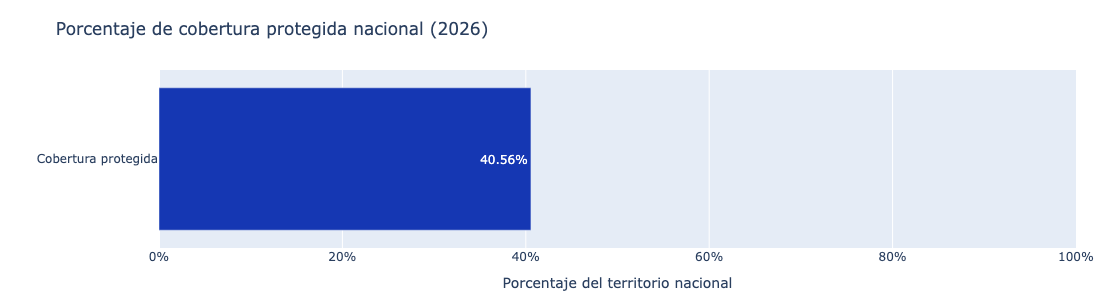

In [6]:
df_first = scdb.head(2).copy()
df_first["Value"] = pd.to_numeric(df_first["Value"], errors="coerce")
df_first["Unit"] = df_first["Unit"].astype(str)

# Obtener fila de porcentaje
coverage_percent = df_first[df_first["Unit"].str.lower().eq("percent")].iloc[0]

# Obtener fila de hectáreas
coverage_ha = df_first[df_first["Unit"].str.lower().eq("hectares")].iloc[0]

valor_percent = float(coverage_percent["Value"])
valor_ha = float(coverage_ha["Value"])
anio = int(coverage_percent["Year"])

fig = go.Figure()

fig.add_trace(go.Bar(
    x=[valor_percent],
    y=["Cobertura protegida"],
    orientation="h",
    text=[f"{valor_percent:.2f}%"],
    textposition="inside",
    marker=dict(color="#1537B3"),
    customdata=[[valor_ha]],
    hovertemplate=(
        "Cobertura protegida<br>"
        "Superficie protegida: %{customdata[0]:,.0f} ha<br>"
        "Porcentaje: %{x:.2f}%"
        "<extra></extra>"
    )
))

fig.update_layout(
    title=f"Porcentaje de cobertura protegida nacional ({anio})",
    xaxis=dict(
        title="Porcentaje del territorio nacional",
        range=[0, 100],
        ticksuffix="%"
    ),
    yaxis=dict(title=""),
    height=300,
    margin=dict(l=80, r=40, t=70, b=50),
    showlegend=False
)

fig.show()

In [ ]:
# Cargar superficie terrestre para cruce con áreas protegidas
from pathlib import Path
import zipfile
chile_url='https://www.bcn.cl/obtienearchivo?id=repositorio/10221/10398/2/Regiones.zip'
zip_path = Path("Regiones.zip")
referer = "https://www.bcn.cl/siit/mapas_vectoriales"
headers = {
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36",
    "Referer": referer,
    "Accept": "*/*",
    "Accept-Language": "es-CL,es;q=0.9,en;q=0.8",
    "Connection": "keep-alive",
}
s = requests.Session()
# 1) “Visita” la página para obtener cookies si las piden
s.get(referer, headers=headers, timeout=60)
# 2) Descarga el ZIP
with s.get(chile_url, headers=headers, stream=True, timeout=120, allow_redirects=True) as r:
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

print("Descargado:", zip_path)
with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()
    shp_files = [n for n in names if n.lower().endswith(".shp")]
    print("SHP encontrados:", shp_files)
shp_inside = shp_files[0]  # elige el correcto si hay más de uno
regiones_gpd = gpd.read_file(f"zip://{zip_path}!{shp_inside}")
regiones_gpd = regiones_gpd.to_crs(epsg=32719)
print("CRS:", regiones_gpd.crs)
regiones_gpd["area_m2"] = regiones_gpd.geometry.apply(
    lambda g: geodesic_area_m2(g, crs=regiones_gpd.crs)
)
regiones_gpd["area_ha"] = regiones_gpd["area_m2"] / 10_000
regiones_gpd["area_km2"] = regiones_gpd["area_ha"] / 100
regiones_gpd_area_total_ha = regiones_gpd["area_ha"].sum()
regiones_gpd_area_total_km2 = regiones_gpd_area_total_ha / 100


In [69]:
regiones_gpd = gpd.read_postgis(
    sql="SELECT * FROM public.regiones",
    con=engine,
    geom_col="geometry",     
    crs="EPSG:32719"      
)
regiones_gpd_area_total_ha = regiones_gpd["area_ha"].sum()
regiones_gpd_area_total_km2 = regiones_gpd_area_total_ha / 100

In [72]:
#Cobertura por Ecosistemas Terrestres
areas_protegidas_terrestres_gpd = gpd.overlay(areas_protegidas_total_gpd, regiones_gpd, how="intersection", keep_geom_type=False)
areas_protegidas_terrestres_gpd_union = areas_protegidas_terrestres_gpd.geometry.union_all()
areas_protegidas_terrestres_gpd_area_total_m2 = geodesic_area_m2(
    areas_protegidas_terrestres_gpd_union,
    crs=areas_protegidas_terrestres_gpd.crs
)
areas_protegidas_terrestres_gpd_area_total_ha = areas_protegidas_terrestres_gpd_area_total_m2 / 10_000
areas_protegidas_terrestres_gpd_area_total_km2 = areas_protegidas_terrestres_gpd_area_total_ha / 100
porcentaje_cobertura_terrestre = round((areas_protegidas_terrestres_gpd_area_total_km2 / regiones_gpd_area_total_km2) * 100,2)

In [77]:
areas_protegidas_terrestres_gpd_area_total_ha = round(areas_protegidas_terrestres_gpd_area_total_ha, 0)
areas_protegidas_terrestres_gpd_area_total_ha_formateado = f"{int(areas_protegidas_terrestres_gpd_area_total_ha):,}".replace(",", ".")

In [135]:
text = f""" 
Ámbito Continental (Terrestre y Dulceacuícola): Se reportan {areas_protegidas_terrestres_gpd_area_total_ha_formateado} hectáreas protegidas, lo que equivale a un {porcentaje_cobertura_terrestre}% de la superficie continental oficial.
"""
#md(text)

In [128]:
# Cargar superficie marina para cruce con áreas protegidas
ecosistemas_marinos_gpd = gpd.read_postgis(
    sql="SELECT * FROM public.ecosistemas_marinos",
    con=engine,
    geom_col="geometry",     
    crs="EPSG:32719"      
)

In [129]:
#Cobertura por Ecosistemas Terrestres
import shapely
areas_protegidas_total_gpd = shapely.make_valid(areas_protegidas_total_gpd_union)

In [130]:
from tqdm.auto import tqdm
new_geoms = []
for g in tqdm(ecosistemas_marinos_gpd.geometry, total=len(ecosistemas_marinos_gpd), desc="Intersección"):
    new_geoms.append(g.intersection(areas_protegidas_total_gpd_union))
ecosistemas_marinos_gpd["geometry"] = new_geoms

Intersección:   0%|          | 0/90 [00:00<?, ?it/s]

In [131]:
ecosistemas_marinos_gpd_area_total_m2 = ecosistemas_marinos_gpd.geometry.apply(
    lambda g: geodesic_area_m2(g, crs=ecosistemas_marinos_gpd.crs)
).sum()

1457151480581.3452


In [133]:
areas_protegidas_marinas_gpd_area_total_ha = ecosistemas_marinos_gpd_area_total_m2 / 10_000
porcentaje_cobertura_marina = round((areas_protegidas_marinas_gpd_area_total_ha / marino_ha) * 100,2)

* Ámbito Continental (Terrestre y Dulceacuícola): Se reportan 17.911.900 hectáreas protegidas, lo que equivale a un 23,67% de la superficie continental oficial.
* Ámbito Marítimo (Marino): Se contabilizan 150.803.300 hectáreas bajo protección formal, lo que representa un 42,77% de la Zona Económica Exclusiva (ZEE) del país, superando la meta cuantitativa del 30% del Marco Mundial de Biodiversidad en este dominio.

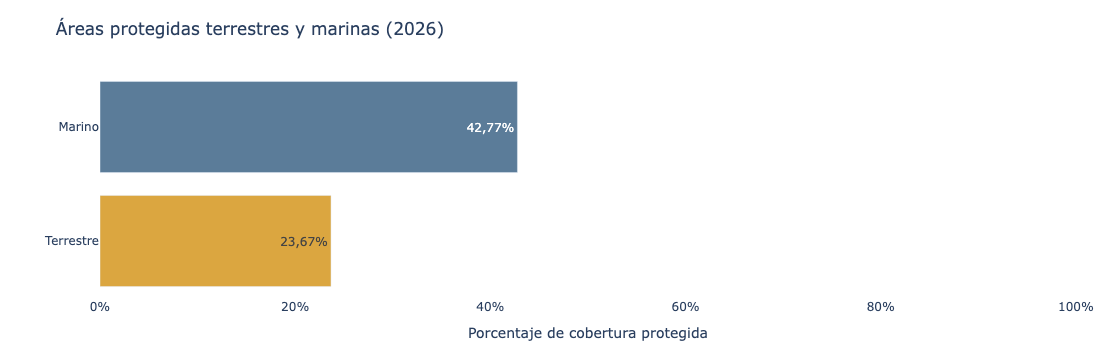

In [7]:
col_h = scdb.columns[7]

# Valores desde posiciones exactas del Excel
ha_terrestre = pd.to_numeric(scdb.iloc[2, 7], errors="coerce")      # fila 4, columna H
pct_terrestre = pd.to_numeric(scdb.iloc[3, 7], errors="coerce")     # fila 5, columna H

ha_marino = pd.to_numeric(scdb.iloc[4, 7], errors="coerce")         # fila 6, columna H
pct_marino = pd.to_numeric(scdb.iloc[5, 7], errors="coerce")        # fila 7, columna H

# Si quieres obtener el año desde la columna Year, usando las mismas filas
anio = int(scdb.loc[scdb.index[4], "Year"]) if "Year" in scdb.columns else ""

# DataFrame para graficar
df_plot = pd.DataFrame({
    "tipo": ["Terrestre", "Marino"],
    "porcentaje": [pct_terrestre, pct_marino],
    "hectareas": [ha_terrestre, ha_marino],
    "color": ["#DBA640", "#5B7C99"]  # un color para cada barra
})

df_plot["porcentaje_txt"] = df_plot["porcentaje"].map(
    lambda x: f"{x:.2f}".replace(".", ",") + "%"
)

df_plot["hectareas_txt"] = df_plot["hectareas"].map(
    lambda x: f"{x:,.0f}".replace(",", ".")
)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_plot["porcentaje"],
    y=df_plot["tipo"],
    orientation="h",
    text=df_plot["porcentaje_txt"],
    textposition="inside",
    marker=dict(
        color=df_plot["color"]
    ),
    customdata=df_plot[["hectareas_txt", "porcentaje_txt"]],
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Superficie protegida: %{customdata[0]} ha<br>"
        "Porcentaje de cobertura: %{customdata[1]}"
        "<extra></extra>"
    )
))

fig.update_layout(
    title=f"Áreas protegidas terrestres y marinas {f'({anio})' if anio else ''}",
    xaxis=dict(
        title="Porcentaje de cobertura protegida",
        range=[0, 100],
        ticksuffix="%"
    ),
    yaxis=dict(
        title="",
        categoryorder="array",
        categoryarray=["Terrestre", "Marino"]
    ),
    height=350,
    margin=dict(l=100, r=40, t=70, b=50),
    showlegend=False,
    paper_bgcolor="white",
    plot_bgcolor="white",
    hoverlabel=dict(
        bgcolor="white",
        font=dict(color="#111827", size=13)
    )
)

fig.show()

In [138]:
#Cobertura por Ecosistema (EFG) y Reino
#EFG Continental
efg_continental_gpd = gpd.read_postgis(
    sql="SELECT * FROM public.efg_continental",
    con=engine,
    geom_col="geometry",     
    crs="EPSG:32718"      
)

In [142]:
efg_continental_gpd = efg_continental_gpd.to_crs("EPSG:32719")

In [143]:
new_geoms = []
for g in tqdm(efg_continental_gpd.geometry, total=len(efg_continental_gpd), desc="Intersección"):
    new_geoms.append(g.intersection(areas_protegidas_total_gpd_union))
efg_continental_gpd["geometry"] = new_geoms

Intersección:   0%|          | 0/171 [00:01<?, ?it/s]

In [144]:
efg_continental_gpd_area_total_m2 = efg_continental_gpd.geometry.apply(
    lambda g: geodesic_area_m2(g, crs=efg_continental_gpd.crs)
).sum()

In [151]:
#Cobertura por Ecosistema (EFG) y Reino
#EFG Marino
efg_marino_gpd = gpd.read_postgis(
    sql="SELECT * FROM public.efg_marino",
    con=engine,
    geom_col="geometry",     
    crs="EPSG:32719"      
)

In [152]:
new_geoms = []
for g in tqdm(efg_marino_gpd.geometry, total=len(efg_marino_gpd), desc="Intersección"):
    new_geoms.append(g.intersection(areas_protegidas_total_gpd_union))
efg_marino_gpd["geometry"] = new_geoms

Intersección:   0%|          | 0/91 [00:00<?, ?it/s]

In [153]:
efg_marino_gpd_area_total_m2 = efg_marino_gpd.geometry.apply(
    lambda g: geodesic_area_m2(g, crs=efg_marino_gpd.crs)
).sum()

### 2. Representatividad Ecológica: Grupos Funcionales de Ecosistemas (EFG)
El análisis de representatividad ecológica muestra variaciones en la proporción de los distintos ecosistemas que están siendo protegidos.

En el territorio continental, el análisis revela una mayor concentración de áreas protegidas hacia el sur del país. La red de conservación presenta una mayor cobertura en ecosistemas criosféricos y forestales de mayores latitudes, como los Campos de hielo, glaciares y nieves perennes (T6.1 Ice sheets, glaciers and perennial snowfields) con una protección del 94,70%. Asimismo, considerando su magnitud territorial, se observan los Bosques húmedos templados fríos oceánicos (T2.3 Oceanic cool temperate rainforests), que cuentan con un 37,84% de su extensión bajo resguardo.

Por el contrario, los ecosistemas ubicados en menores latitudes (zona norte y centro) presentan proporciones de protección menores. Grupos funcionales áridos y semiáridos como los Desiertos hiperaridos (T5.5 Hyper-arid deserts) con un 1,10%, las Estepas semidesérticas (T5.1 Semi-desert steppe) con 2%, y los Desiertos y semidesiertos suculentos y espinosos (T5.4 Succulent or Thorny deserts and semi-deserts) con 3,17%, muestran una menor superficie protegida en comparación al total nacional.

En cuanto a los ecosistemas acuáticos continentales y transicionales, la cobertura se distribuye de la siguiente manera:
* Sistemas Transicionales (TF): Las Turberas boreales, templadas y montañas (TF1.6) presentan un 85,82% de protección. Por su parte, los Pantanos boreales y templados (TF1.7 Boreal and temperate fens) alcanzan un 19,00%, y las marismas o llanuras de inundación estacional (TF1.4 Seasonal floodplain marshes) muestran un 8,2% de su superficie en áreas protegidas.
* Sistemas Dulceacuícolas Estrictos (F): Se observan menores niveles de cobertura en ecosistemas como los Lagos de sal o salares (F2.6 Permanent salt and soda lakes) con 16,03%, los Grandes lagos permanentes de agua dulce (F2.1 Large permanent freshwater lakes) con 31,3% y los Ríos permanentes de tierras bajas (F1.2 Permanent lowland rivers) con 15,83%.
  
En el territorio marítimo, la cobertura general (42,77%) está influenciada por la protección de ecosistemas pelágicos y oceánicos profundos de gran extensión. El EFG con mayor proporción protegida corresponde a los Montes submarinos, dorsales y mesetas (M3.4 Seamounts, ridges and plateaus) con un 72,30% de su superficie, seguido por los Taludes continentales e insulares (M3.1) con un 43,44%.

Por otro lado, el análisis indica una menor proporción de protección en los ecosistemas bentónicos costeros. Por ejemplo, los Lechos de arena submareales (M1.4 Subtidal sand beds) cuentan con un 1,75% de su extensión protegida, las Costas arenosas (MT1.3 Sandy Shorelines) un 2,12%, y los Arrecifes rocosos submareales (M1.6) un 10,70%.



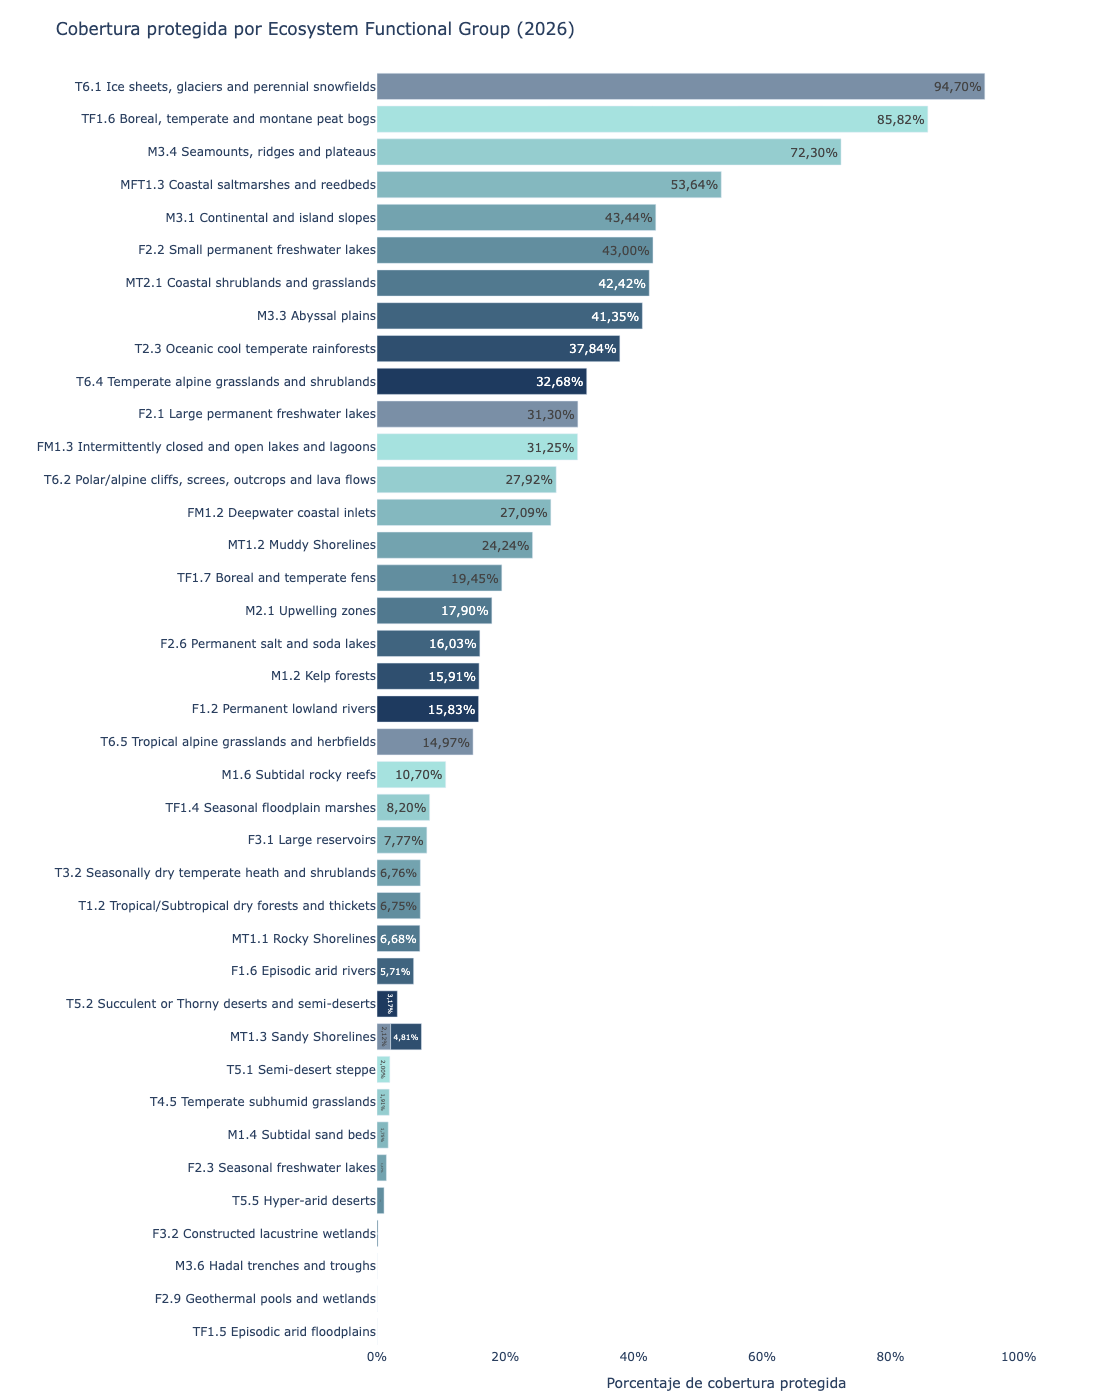

In [10]:
df_plot = scdb.copy()

# Normalizar columnas
df_plot["Value"] = pd.to_numeric(df_plot["Value"], errors="coerce")
df_plot["Unit"] = df_plot["Unit"].astype(str)
df_plot["Disaggregation type"] = df_plot["Disaggregation type"].astype(str)
df_plot["Disaggregation"] = df_plot["Disaggregation"].astype(str)

# Filtrar solo Ecosystem Functional Group con valores porcentuales
df_graph = df_plot[
    (df_plot["Disaggregation type"].str.strip() == "Ecosystem Functional Group") &
    (df_plot["Unit"].str.strip().str.lower() == "percent")
].copy()

# Eliminar filas sin valor o sin nombre de desagregación
df_graph = df_graph.dropna(subset=["Value"])
df_graph = df_graph[df_graph["Disaggregation"].str.strip().ne("")]

# Ordenar de menor a mayor para que el mayor quede arriba en barra horizontal
df_graph = df_graph.sort_values("Value", ascending=True)

# Formato de porcentaje
df_graph["porcentaje_txt"] = df_graph["Value"].map(
    lambda x: f"{x:.2f}".replace(".", ",") + "%"
)

# Año, si existe
anio = ""
if "Year" in df_graph.columns and df_graph["Year"].notna().any():
    anio = int(df_graph["Year"].dropna().iloc[0])

# Colores sobrios por barra
base_colors = [
    "#1E3A5F", "#2F4F6F", "#40647F", "#51798F", "#628E9F",
    "#73A3AF", "#84B8BF", "#95CDCF", "#A6E2DF", "#7A8FA6"
]

colors = [base_colors[i % len(base_colors)] for i in range(len(df_graph))]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=df_graph["Value"],
    y=df_graph["Disaggregation"],
    orientation="h",
    text=df_graph["porcentaje_txt"],
    textposition="inside",
    marker=dict(color=colors),
    customdata=df_graph[["porcentaje_txt"]],
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Porcentaje de cobertura: %{customdata[0]}"
        "<extra></extra>"
    )
))

fig.update_layout(
    title=f"Cobertura protegida por Ecosystem Functional Group {f'({anio})' if anio else ''}",
    xaxis=dict(
        title="Porcentaje de cobertura protegida",
        range=[0, max(df_graph["Value"].max() * 1.15, 10)],
        ticksuffix="%"
    ),
    yaxis=dict(
        title="",
        automargin=True
    ),
    height=max(450, 35 * len(df_graph)),
    margin=dict(l=260, r=40, t=70, b=50),
    showlegend=False,
    paper_bgcolor="white",
    plot_bgcolor="white",
    hoverlabel=dict(
        bgcolor="white",
        bordercolor="#1E3A5F",
        font=dict(color="#111827", size=13)
    )
)

fig.show()

## Observaciones
La Meta 3 del Marco Mundial exige que la conservación del 30% del territorio se logre reconociendo y respetando los territorios tradicionales indígenas. A nivel nacional, la reciente Ley N° 21.600 del Ministerio del Medio Ambiente dio un paso normativo histórico al crear la nueva categoría de "Área de Conservación de Pueblos Indígenas" (Artículos 56 y 62), diseñada para integrar formalmente al sistema nacional las áreas administradas voluntariamente por comunidades locales.

Sin embargo, a la fecha de este reporte, no existen hectáreas contabilizadas bajo esta figura. Dado que es una categoría de creación voluntaria y no sujeta a homologación automática desde figuras previas, su implementación depende de la aprobación de los reglamentos pendientes de la Ley N° 21.600. Por lo tanto, la actual métrica de cobertura de áreas protegidas de Chile presenta un vacío de representatividad, ya que no contabiliza los esfuerzos efectivos de conservación que las comunidades indígenas ya realizan de facto en sus territorios (ej. mediante ECMPOs con fines de conservación o tierras indígenas protegidas), invisibilizando su aporte al cumplimiento de la Meta 3 hasta que el nuevo mecanismo de solicitud entre en plena vigencia.

## Brechas
Existen brechas y procesos técnicos en curso que limitan el desarrollo completo de todas las desagregaciones sugeridas por el indicador 3.1:
1. Otras Medidas de Conservación Eficaces Basadas en Áreas (OMEC): A la fecha, Chile no reporta OMEC. El país se encuentra en un proceso de definición técnica exhaustivo para estas áreas, cuyo objetivo principal es garantizar que cuenten con una gobernanza y una gestión efectivamente demostrables antes de integrarlas formalmente a los reportes nacionales e internacionales.
2. Evaluación de la Gestión Efectiva: Actualmente no es posible reportar la desagregación por efectividad de gestión exigida por el indicador. El país no cuenta aún con una métrica oficial, estandarizada y transversal a toda la red de áreas protegidas que permita medir si los planes de manejo logran los resultados biológicos esperados.
3. Áreas Clave para la Biodiversidad (KBA): No se incluyó la desagregación por KBA, dado que esta categoría no constituye una figura oficial del Estado de Chile. Si bien el país cuenta con una figura nacional análoga denominada Sitios Prioritarios para la Conservación, estos son por definición y normativa legal excluyentes con las Áreas Protegidas (una vez que un área se protege formalmente, deja de ser un 'Sitio Prioritario'). Esto imposibilita matemáticamente el cálculo de superposición que exige el CBD para medir qué porcentaje de los sitios clave está cubierto por áreas protegidas.